# MNIST LFU experiment command center

In [1]:
from pathlib import Path
import sys
import math
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "src").is_dir():
    REPO_ROOT = Path.cwd().parent
if not (REPO_ROOT / "src").is_dir():
    raise RuntimeError("Run this notebook from the repository root or mnist_experiment directory")
sys.path.insert(0, str(REPO_ROOT))

from src.results_analysis import (
    discover_phase4_runs,
    load_selected_phase3_runs,
    normalized_phase4_condition_rows,
    phase3_convergence_rows,
    phase3_diagnostic_rows,
    phase3_stencil_rows,
    phase4_cost_rows,
    phase4_replica_summaries,
    select_phase4_condition_evidence,
    select_principal_phase4_runs,
    validate_common_parameter_layout,
)

plt.style.use("seaborn-v0_8-whitegrid")
COLORS = {
    "ema": "#1f77b4",
    "periodic_fresh": "#2ca02c",
    "ac_only": "#d62728",
    "full_lfu": "#9467bd",
    "ridge_ac_only": "#ff7f0e",
    "ridge_full_lfu": "#17becf",
}
PHASE3_ROOT = REPO_ROOT / "cache/mnist_experiment/phase3_runs"
PHASE4_ROOT = REPO_ROOT / "cache/mnist_experiment/runs"

phase3_runs = load_selected_phase3_runs(PHASE3_ROOT)
discovered_phase4_runs = discover_phase4_runs(PHASE4_ROOT)
principal_phase4_runs = select_principal_phase4_runs(discovered_phase4_runs)
layout_hash = validate_common_parameter_layout(principal_phase4_runs)
selected_rows, principal_inventory = select_phase4_condition_evidence(principal_phase4_runs)

convergence = pd.DataFrame(phase3_convergence_rows(phase3_runs))
stencils = pd.DataFrame(phase3_stencil_rows(phase3_runs))
phase3_diagnostics = pd.DataFrame(phase3_diagnostic_rows(phase3_runs))
tracking = pd.DataFrame(selected_rows)
replica_summaries = pd.DataFrame(phase4_replica_summaries(selected_rows))
costs = pd.DataFrame(phase4_cost_rows(principal_phase4_runs))
inventory = pd.DataFrame(principal_inventory)
print(f"Loaded {len(phase3_runs)} accepted Phase 3 runs and {len(principal_phase4_runs)} principal tracking runs.")
print(f"Structural parameter-layout hash: {layout_hash[:16]}")

from IPython.display import display
from src.phase9 import discover_phase9_bundles
from src.plan2 import discover_plan2_bundles
from src.plan2_analysis import (
    combined_plan2_trajectory_rows,
    plan2_condition_semantics_rows,
    plan2_inventory_rows,
    plan2_m128_anchor_rows,
    plan2_progress_rows,
    plan2_trajectory_rows,
)
from src.results_analysis import (
    phase9_inventory_rows,
    phase9_paired_aggregates,
    phase9_paired_rows,
    phase9_progress_rows,
    phase9_replica_rows,
    phase9_trajectory_rows,
    phase9_expected_trajectory_rows,
    phase9_durable_crossing_rows,
    phase9_metric_availability_rows,
    require_phase9_metrics,
)

PHASE9_ROOT = REPO_ROOT / "cache/mnist_experiment/phase9/bundles"
phase9_bundles = discover_phase9_bundles(PHASE9_ROOT)
if not phase9_bundles:
    raise RuntimeError("No prepared Phase 9 bundles were found.")
phase9_inventory = pd.DataFrame(phase9_inventory_rows(phase9_bundles, REPO_ROOT))
phase9_progress = pd.DataFrame(phase9_progress_rows(phase9_inventory.to_dict("records")))
phase9_replicas = pd.DataFrame(phase9_replica_rows(phase9_bundles, REPO_ROOT))
phase9_pairs = pd.DataFrame(phase9_paired_rows(phase9_replicas.to_dict("records")))
phase9_effects = pd.DataFrame(phase9_paired_aggregates(phase9_pairs.to_dict("records")))
phase9_trajectory_records = phase9_trajectory_rows(phase9_bundles, REPO_ROOT)
phase9_trajectories = pd.DataFrame(phase9_trajectory_records)
phase9_availability = pd.DataFrame(
    phase9_metric_availability_rows(
        phase9_trajectory_records,
        metrics=(
            "after_nine_ovr_accuracy",
            "after_nine_precision",
            "after_nine_recall",
            "after_nine_accuracy",
            "after_non_nine_accuracy",
            "after_environment_accuracy",
            "after_brier",
            "after_expected_calibration_error",
        ),
    )
)

PLAN2_ROOT = REPO_ROOT / "cache/mnist_experiment/plan2/bundles"
plan2_bundles = discover_plan2_bundles(PLAN2_ROOT)
plan2_inventory_records = plan2_inventory_rows(plan2_bundles, REPO_ROOT)
plan2_inventory = pd.DataFrame(plan2_inventory_records)
plan2_condition_semantics = pd.DataFrame(plan2_condition_semantics_rows())
plan2_progress = pd.DataFrame(plan2_progress_rows(plan2_inventory_records))
plan2_anchor_records = plan2_m128_anchor_rows(
    phase9_trajectory_records,
    replica_indices=(1, 2, 3),
)
plan2_run_records = plan2_trajectory_rows(plan2_bundles, REPO_ROOT)
plan2_combined_records = combined_plan2_trajectory_rows(
    plan2_run_records,
    plan2_anchor_records,
)


Loaded 2 accepted Phase 3 runs and 8 principal tracking runs.
Structural parameter-layout hash: f6861caab1a033bf


## Phase 9 command center

Prepared bundles are immutable experimental intentions. This view reports what is expected, completed, and paired without launching compute. The initial screening target is five independent paired replicas per cell. See [experimental conditions](EXPERIMENTAL_CONDITIONS.md) for the shared LFU mechanics and exact meaning of each condition.

,bundle_id,profiles,replicas,runs,estimated_gpu_hours,estimated_storage_gib,path
0,phase9-initial__r0001-r0005__01cd8063b260,controller-screen,5,40,7.791667,2.235174,/home/evan/Documents/notebooks/amari-chenstov-...
1,phase9-initial__r9001__e3aaaf88ac24,smoke,1,2,0.051667,0.000279,/home/evan/Documents/notebooks/amari-chenstov-...


,profile,run_state,runs
0,controller-screen,completed,40
1,smoke,completed,2


,profile,cell,expected_replicas,completed_treatments,completed_pairs,initial_target,initial_target_met
0,controller-screen,center,5,5,5,5,True
1,controller-screen,pi-max-080,5,5,5,5,True
2,controller-screen,pi-max-100,5,5,5,5,True
3,controller-screen,pi-min-001,5,5,5,5,True
4,controller-screen,pi-min-010,5,5,5,5,True
5,controller-screen,trend-h-010,5,5,5,5,True
6,controller-screen,trend-h-040,5,5,5,5,True
7,smoke,center,1,1,1,5,False


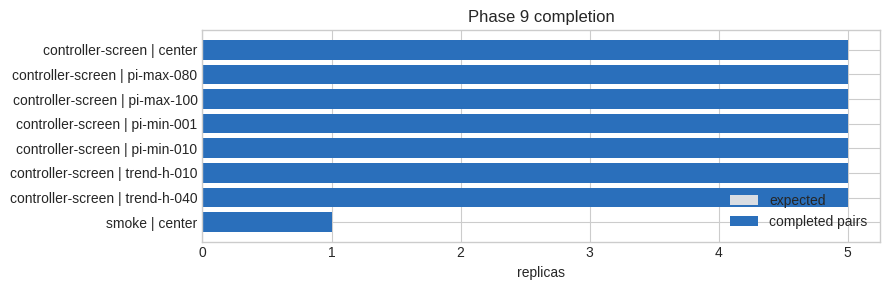

In [2]:
bundle_inventory = pd.DataFrame([
    {
        "bundle_id": bundle.bundle_id,
        "profiles": ", ".join(bundle.manifest["selection"]["profiles"]),
        "replicas": len(bundle.manifest["selection"]["replica_indices"]),
        "runs": bundle.manifest["entry_count"],
        "estimated_gpu_hours": bundle.manifest["estimated_seconds"] / 3600.0,
        "estimated_storage_gib": bundle.manifest["estimated_bytes"] / 2**30,
        "path": str(bundle.path),
    }
    for bundle in phase9_bundles
])
display(bundle_inventory)
state_counts = (phase9_inventory.groupby(["profile", "run_state"]).size().rename("runs").reset_index())
display(state_counts)
display(phase9_progress)

progress_plot = phase9_progress.copy()
progress_plot["label"] = progress_plot["profile"] + " | " + progress_plot["cell"]
fig, ax = plt.subplots(figsize=(9, max(3, 0.34 * len(progress_plot))))
positions = list(range(len(progress_plot)))
ax.barh(positions, progress_plot["expected_replicas"], color="#d9dde3", label="expected")
ax.barh(positions, progress_plot["completed_pairs"], color="#2a6fbb", label="completed pairs")
ax.set(yticks=positions, yticklabels=progress_plot["label"], xlabel="replicas", title="Phase 9 completion")
ax.invert_yaxis()
ax.legend()
plt.tight_layout()


### Paired controller evidence

Effects are treatment minus the explicitly named control within each replica. Positive accuracy effects and negative NLL effects favor the treatment. See [experimental conditions](EXPERIMENTAL_CONDITIONS.md) for each contrast's direction. Intervals are unavailable for a single replica and trajectory points are never counted as independent observations.

,profile,cell,method,metric,replica_count,mean_paired_effect,ci95_low,ci95_high,initial_replica_target_met,treatment_run_ids,control_run_ids
0,controller-screen,center,low_rank_diagonal_r8,environment_accuracy_auc,5,0.015851,-0.006660,0.038362,True,[mnist_lfu_phase9_controller-screen_center_plu...,[mnist_lfu_phase9_controller-screen_control_fi...
1,controller-screen,center,low_rank_diagonal_r8,environment_nll_auc,5,-0.063046,-0.163379,0.037287,True,[mnist_lfu_phase9_controller-screen_center_plu...,[mnist_lfu_phase9_controller-screen_control_fi...
2,controller-screen,center,low_rank_diagonal_r8,final_balanced_accuracy,5,0.101327,-0.036503,0.239157,True,[mnist_lfu_phase9_controller-screen_center_plu...,[mnist_lfu_phase9_controller-screen_control_fi...
8,controller-screen,center,low_rank_diagonal_r8,nine_accuracy_auc,5,0.017551,-0.017181,0.052283,True,[mnist_lfu_phase9_controller-screen_center_plu...,[mnist_lfu_phase9_controller-screen_control_fi...
9,controller-screen,center,low_rank_diagonal_r8,nine_nll_auc,5,-0.109293,-0.342714,0.124128,True,[mnist_lfu_phase9_controller-screen_center_plu...,[mnist_lfu_phase9_controller-screen_control_fi...
10,controller-screen,center,low_rank_diagonal_r8,non_nine_accuracy_auc,5,0.033971,-0.008420,0.076362,True,[mnist_lfu_phase9_controller-screen_center_plu...,[mnist_lfu_phase9_controller-screen_control_fi...
12,controller-screen,pi-max-080,low_rank_diagonal_r8,environment_accuracy_auc,5,0.015851,-0.006660,0.038362,True,[mnist_lfu_phase9_controller-screen_pi-max-080...,[mnist_lfu_phase9_controller-screen_control_fi...
13,controller-screen,pi-max-080,low_rank_diagonal_r8,environment_nll_auc,5,-0.063046,-0.163379,0.037287,True,[mnist_lfu_phase9_controller-screen_pi-max-080...,[mnist_lfu_phase9_controller-screen_control_fi...
14,controller-screen,pi-max-080,low_rank_diagonal_r8,final_balanced_accuracy,5,0.101327,-0.036503,0.239157,True,[mnist_lfu_phase9_controller-screen_pi-max-080...,[mnist_lfu_phase9_controller-screen_control_fi...
20,controller-screen,pi-max-080,low_rank_diagonal_r8,nine_accuracy_auc,5,0.017551,-0.017181,0.052283,True,[mnist_lfu_phase9_controller-screen_pi-max-080...,[mnist_lfu_phase9_controller-screen_control_fi...


,profile,cell,replica_id,treatment_run_path,control_run_path
0,controller-screen,center,replica-0001,/home/evan/Documents/notebooks/amari-chenstov-...,/home/evan/Documents/notebooks/amari-chenstov-...
1,controller-screen,center,replica-0002,/home/evan/Documents/notebooks/amari-chenstov-...,/home/evan/Documents/notebooks/amari-chenstov-...
2,controller-screen,center,replica-0003,/home/evan/Documents/notebooks/amari-chenstov-...,/home/evan/Documents/notebooks/amari-chenstov-...
3,controller-screen,center,replica-0004,/home/evan/Documents/notebooks/amari-chenstov-...,/home/evan/Documents/notebooks/amari-chenstov-...
4,controller-screen,center,replica-0005,/home/evan/Documents/notebooks/amari-chenstov-...,/home/evan/Documents/notebooks/amari-chenstov-...
5,controller-screen,pi-max-080,replica-0001,/home/evan/Documents/notebooks/amari-chenstov-...,/home/evan/Documents/notebooks/amari-chenstov-...
6,controller-screen,pi-max-080,replica-0002,/home/evan/Documents/notebooks/amari-chenstov-...,/home/evan/Documents/notebooks/amari-chenstov-...
7,controller-screen,pi-max-080,replica-0003,/home/evan/Documents/notebooks/amari-chenstov-...,/home/evan/Documents/notebooks/amari-chenstov-...
8,controller-screen,pi-max-080,replica-0004,/home/evan/Documents/notebooks/amari-chenstov-...,/home/evan/Documents/notebooks/amari-chenstov-...
9,controller-screen,pi-max-080,replica-0005,/home/evan/Documents/notebooks/amari-chenstov-...,/home/evan/Documents/notebooks/amari-chenstov-...


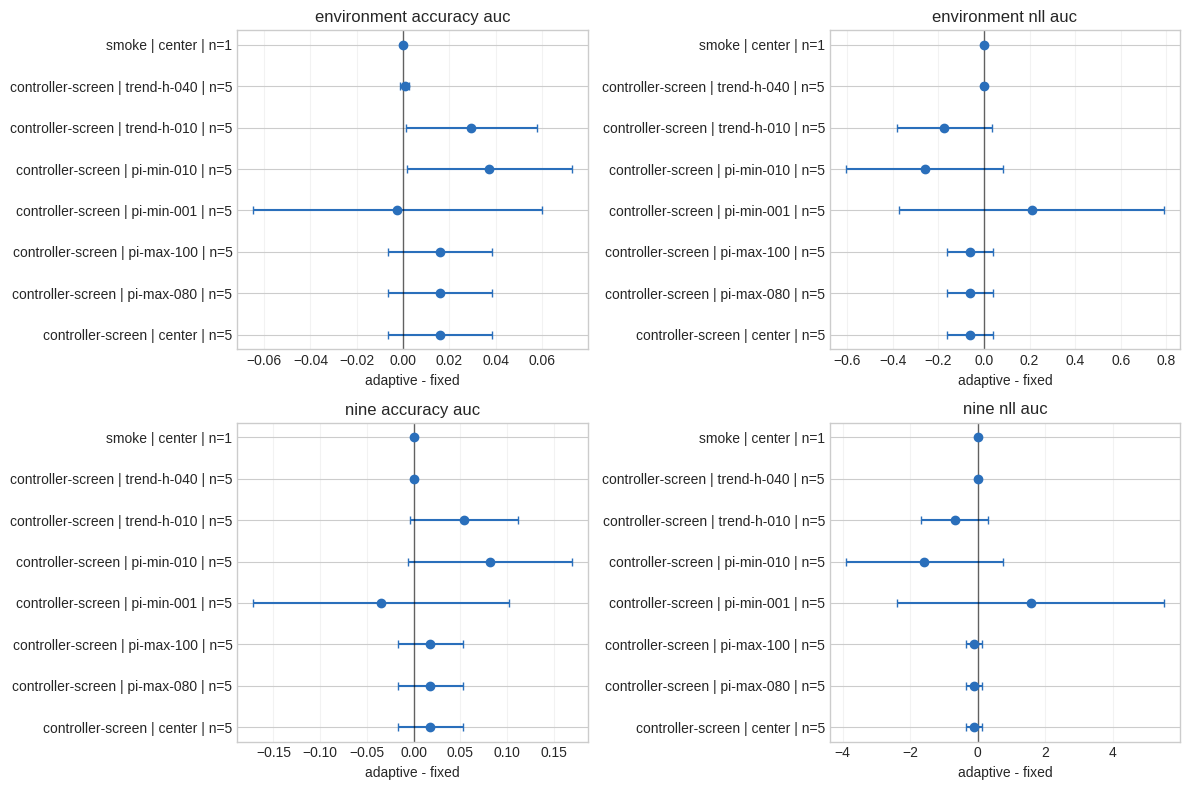

In [3]:
primary_metrics = [
    "environment_accuracy_auc",
    "environment_nll_auc",
    "nine_accuracy_auc",
    "nine_nll_auc",
    "non_nine_accuracy_auc",
    "final_balanced_accuracy",
]
primary_effects = phase9_effects[phase9_effects["metric"].isin(primary_metrics)].copy()
display(primary_effects[[
    "profile", "cell", "method", "metric", "replica_count",
    "mean_paired_effect", "ci95_low", "ci95_high",
    "initial_replica_target_met", "treatment_run_ids", "control_run_ids",
]])

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
plot_metrics = ["environment_accuracy_auc", "environment_nll_auc", "nine_accuracy_auc", "nine_nll_auc"]
for axis, metric in zip(axes.flat, plot_metrics):
    subset = primary_effects[primary_effects["metric"] == metric].reset_index(drop=True)
    for index, row in subset.iterrows():
        error = None if pd.isna(row["ci95_low"]) else [[row["mean_paired_effect"] - row["ci95_low"]], [row["ci95_high"] - row["mean_paired_effect"]]]
        axis.errorbar(row["mean_paired_effect"], index, xerr=error, fmt="o", color="#2a6fbb", capsize=3)
    labels = subset["profile"] + " | " + subset["cell"] + " | n=" + subset["replica_count"].astype(str)
    axis.set(yticks=range(len(subset)), yticklabels=labels, xlabel="treatment - named control", title=metric.replace("_", " "))
    axis.axvline(0.0, color="black", linewidth=1, alpha=0.6)
    axis.grid(axis="x", alpha=0.25)
plt.tight_layout()

provenance_columns = ["profile", "cell", "replica_id", "treatment_run_path", "control_run_path"]
display(phase9_pairs[provenance_columns] if not phase9_pairs.empty else phase9_pairs)


### Supplemental diagnostics

Detailed views remain in [coupled results](coupled_results.ipynb), [representation results](representation_results.ipynb), and [controller results](controller_results.ipynb). This notebook keeps only cross-phase status and selected conclusions.

## Historical measurement readiness

This artifact-only view checks the exposure-aware contract of the completed schema-7 adaptation screen. Its legacy `nine_accuracy` field is 9 recall, not a false-positive-sensitive accuracy. It remains useful provenance but has been superseded as a Plan 2 target by the four-metric contract below.


In [ ]:
PLAN2_READINESS_CONDITIONS = {
    "lfu-isolation": ("adaptive-h010-no-lfu",),
    "adaptation-screen": (
        "adaptive-h020-no-lfu",
        "adaptive-h040-no-lfu",
        "fixed-100-no-ewc",
    ),
}
PLAN2_TARGET_METRICS = (
    "after_nine_ovr_accuracy",
    "after_nine_precision",
    "after_nine_recall",
    "after_environment_accuracy",
)
PLAN2_LEGACY_METRICS = (
    "after_nine_accuracy",
    "after_non_nine_accuracy",
    "after_environment_accuracy",
)

availability_records = phase9_availability.to_dict("records")
for profile, cells in PLAN2_READINESS_CONDITIONS.items():
    require_phase9_metrics(
        availability_records,
        profile=profile,
        cells=cells,
        metrics=PLAN2_LEGACY_METRICS,
    )

readiness_mask = pd.Series(False, index=phase9_availability.index)
for profile, cells in PLAN2_READINESS_CONDITIONS.items():
    readiness_mask |= (
        phase9_availability["profile"].eq(profile)
        & phase9_availability["cell"].isin(cells)
    )
readiness = phase9_availability.loc[
    readiness_mask
    & phase9_availability["metric"].isin(
        PLAN2_LEGACY_METRICS + ("after_brier", "after_expected_calibration_error")
    ),
    [
        "profile",
        "cell",
        "metric",
        "completed_replicas",
        "replicas_with_complete_metric",
        "metric_complete",
    ],
]
display(readiness.reset_index(drop=True))

print("Historical nine_accuracy is interpreted explicitly as 9 recall.")


## Plan 2 launch readiness and results

This artifact-only panel validates every prepared nested-stream dependency, confirms the reused $m=128$ anchors, and reports completed low-data trajectories. The primary plots are 9 OvR accuracy, 9 precision, 9 recall, and environmental multiclass accuracy, each averaged across replicas separately at every $p_t$. Missing schema-7 classification backfills are reported rather than approximated from recall.

The original learner and auxiliary Fisher tracker are coupled but distinct. In `no-ewc-pi100`, the learner uses only the current batch and, after initialization, the Fisher diagnostic is the instantaneous empirical $Z_t$ from that batch. Its rank does not measure the rank of information learned by the optimizer.

In [ ]:
if not plan2_bundles:
    raise RuntimeError("No prepared production Plan 2 bundles were found.")
if plan2_progress.empty:
    raise RuntimeError("Prepared Plan 2 bundles contain no run intentions.")
if not bool(plan2_progress["dependencies_ready"].all()):
    raise RuntimeError("At least one Plan 2 stream or reference dependency is unavailable.")

display(plan2_condition_semantics.reset_index(drop=True))
display(plan2_progress.reset_index(drop=True))
print(
    f"Prepared {len(plan2_inventory)} unique Plan 2 runs; "
    f"{int(plan2_progress['completed_runs'].sum())} are complete."
)
print(
    f"Loaded {len(plan2_anchor_records)} scalar trajectory points from the "
    "three compatible m=128 Phase 9 anchors."
)

if plan2_run_records:
    plan2_availability = pd.DataFrame(
        phase9_metric_availability_rows(
            plan2_combined_records, metrics=PLAN2_TARGET_METRICS
        )
    )
    display(plan2_availability.reset_index(drop=True))
    target_metrics_ready = (
        not plan2_availability.empty
        and bool(plan2_availability["metric_complete"].all())
    )
    if target_metrics_ready:
        plan2_expected_records = phase9_expected_trajectory_rows(
            plan2_combined_records, metrics=PLAN2_TARGET_METRICS
        )
        plan2_low_data_expected = pd.DataFrame(plan2_expected_records)
        PLAN2_VIEW_M = 8
        labels = {
            "after_nine_ovr_accuracy": "9 OvR accuracy",
            "after_nine_precision": "9 precision",
            "after_nine_recall": "9 recall",
            "after_environment_accuracy": "Environmental multiclass accuracy",
        }
        fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
        for ax, metric in zip(axes.flat, PLAN2_TARGET_METRICS):
            for condition in sorted(plan2_low_data_expected["cell"].unique()):
                curve = plan2_low_data_expected[
                    plan2_low_data_expected["samples_per_step"].eq(PLAN2_VIEW_M)
                    & plan2_low_data_expected["cell"].eq(condition)
                    & plan2_low_data_expected["metric"].eq(metric)
                ].sort_values("p")
                if curve.empty:
                    continue
                x = curve["p"].astype(float)
                mean = curve["mean"].astype(float)
                ax.plot(x, mean, label=condition)
                if curve["standard_deviation"].notna().all():
                    sd = curve["standard_deviation"].astype(float)
                    ax.fill_between(x, (mean - sd).clip(0, 1), (mean + sd).clip(0, 1), alpha=0.12)
            ax.set_title(labels[metric])
            ax.set_ylim(0, 1)
            ax.set_xlabel("Environmental mixture p")
        axes[0, 0].set_ylabel("Pointwise replica mean")
        axes[1, 0].set_ylabel("Pointwise replica mean")
        axes[0, 0].legend()
        fig.suptitle(f"Plan 2 target trajectories at m={PLAN2_VIEW_M}; bands are +/-1 SD")
        fig.tight_layout()
        plt.show()
    else:
        plan2_low_data_expected = pd.DataFrame()
        print("Target metrics await the immutable classification backfill; no recall-only substitute is plotted.")
else:
    plan2_availability = pd.DataFrame()
    plan2_low_data_expected = pd.DataFrame()
    print("No Plan 2 production trajectories are complete yet.")


## Artifact provenance

Only the explicitly accepted Phase 4 ridge baseline and experiments named with the `mnist_lfu_phase5_` prefix enter principal summaries. Schema-v1 runs remain discoverable, but an overlapping schema-v2 condition supersedes them. Repeated raw controls from ridge half-life runs contribute once.

In [4]:
discovered_inventory = pd.DataFrame([
    {
        "run_id": run.run_id,
        "schema": run.metric_schema_version,
        "K": run.config.data.num_p_steps,
        "m": run.config.data.samples_per_step,
        "principal": run.run_id in {item.run_id for item in principal_phase4_runs},
    }
    for run in discovered_phase4_runs
])
print(discovered_inventory.to_string(index=False))
print("\nPrincipal evidence precedence:\n", inventory.to_string(index=False))

                                                         run_id  schema  K   m  principal
     mnist_lfu_phase4_gpu_pilot__replica-0000__91c84352b9448727       1 21 128      False
mnist_lfu_phase4_gpu_small_step__replica-0000__c55ada9fbfd361fd       1 21 128      False
   mnist_lfu_phase4_ridge_pilot__replica-0000__8294cf954c52cb00       2 21 128       True
   mnist_lfu_phase4_ridge_smoke__replica-0000__c7a8c06938466557       2  3   2      False
         mnist_lfu_phase4_smoke__replica-0000__5bba6fc2f3d31a95       1  3   2      False
      mnist_lfu_phase5_alpha010__replica-0000__9135e509cabb6c2a       2 21 128       True
      mnist_lfu_phase5_alpha050__replica-0000__e24f45e4726afd21       2 21 128       True
       mnist_lfu_phase5_k21_m64__replica-0000__15143966ddd1b113       2 21  64       True
       mnist_lfu_phase5_k9_m128__replica-0000__1c3020348d62e0e8       2  9 128       True
        mnist_lfu_phase5_k9_m64__replica-0000__5b7be59b7c87f6aa       2  9  64       True
     mnist

## Assumption checks

These panels reproduce stored Phase 3 evidence. The weighted central stencil differentiates the full moving-measure Fisher and targets $(C+R):v$; the unweighted paired stencil holds the measure fixed and targets $R:v$.

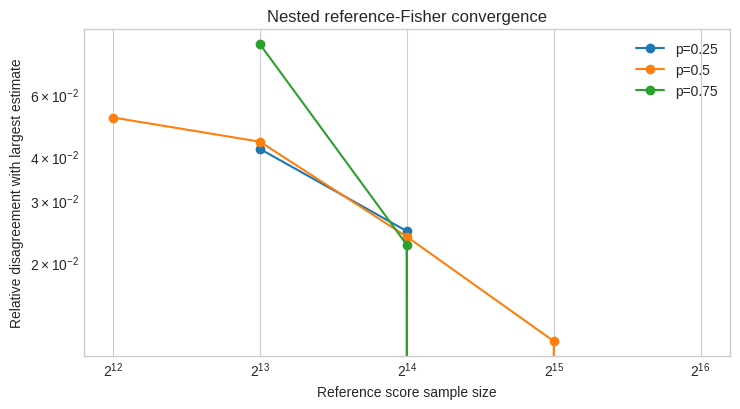

In [5]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
for p_value, group in convergence.groupby("p"):
    ax.plot(group["sample_size"], group["relative_to_largest"], marker="o", label=f"p={p_value:g}")
ax.set_xscale("log", base=2)
ax.set_yscale("log")
ax.set_xlabel("Reference score sample size")
ax.set_ylabel("Relative disagreement with largest estimate")
ax.set_title("Nested reference-Fisher convergence")
ax.legend()
fig.tight_layout()

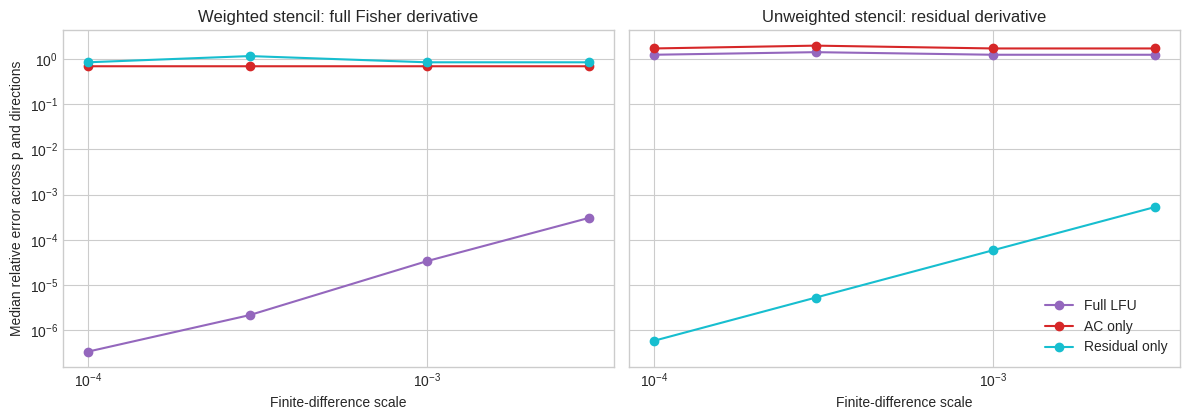

In [6]:
max_sample = stencils.groupby("p")["sample_size"].transform("max")
final_stencils = stencils[stencils["sample_size"] == max_sample].copy()
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3), sharey=True)
for axis, (kind, title) in zip(
    axes,
    [("weighted", "Weighted stencil: full Fisher derivative"), ("unweighted", "Unweighted stencil: residual derivative")],
):
    subset = final_stencils[final_stencils["stencil_kind"] == kind]
    for metric, label, color in [
        ("full_relative_error", "Full LFU", "#9467bd"),
        ("ac_relative_error", "AC only", "#d62728"),
        ("residual_relative_error", "Residual only", "#17becf"),
    ]:
        grouped = subset.groupby("epsilon")[metric].median()
        axis.plot(grouped.index, grouped.values, marker="o", label=label, color=color)
    axis.set_xscale("log")
    axis.set_yscale("log")
    axis.set_xlabel("Finite-difference scale")
    axis.set_title(title)
axes[0].set_ylabel("Median relative error across p and directions")
axes[1].legend()
fig.tight_layout()

In [7]:
weights = final_stencils[final_stencils["stencil_kind"] == "weighted"].copy()
weights["minimum_ess_fraction"] = weights[["plus_effective_sample_size", "minus_effective_sample_size"]].min(axis=1) / weights["sample_size"]
weight_summary = weights.groupby(["p", "epsilon"], as_index=False).agg(
    plus_weight_mean=("plus_weight_mean", "mean"),
    minus_weight_mean=("minus_weight_mean", "mean"),
    minimum_ess_fraction=("minimum_ess_fraction", "min"),
)
print(weight_summary.to_string(index=False, float_format=lambda value: f"{value:.6g}"))

   p  epsilon  plus_weight_mean  minus_weight_mean  minimum_ess_fraction
0.25   0.0003          0.999947            1.00005              0.999998
 0.5   0.0001          0.999992            1.00001                     1
 0.5   0.0003          0.999975            1.00002              0.999996
 0.5    0.001          0.999914            1.00008               0.99996
 0.5    0.003           0.99972            1.00021              0.999629
0.75   0.0003          0.999944            1.00006              0.999998


In [8]:
diagnostics_display = phase3_diagnostics.copy()
diagnostics_display["peak_cuda_memory_mib"] = diagnostics_display["peak_cuda_memory_bytes"] / 2**20
print(diagnostics_display[[
    "p", "selected_reference_sample_size", "reference_elapsed_seconds",
    "lfu_elapsed_seconds", "minimum_eigenvalue", "maximum_eigenvalue",
    "eigendecomposition_elapsed_seconds", "peak_cuda_memory_mib",
]].to_string(index=False, float_format=lambda value: f"{value:.6g}"))
print("\nRoutine reference N=32,768; maximum-quality N=65,536.")
print("Canonical epsilon=3e-4; sensitivity values are 1e-4 and 1e-3.")

   p  selected_reference_sample_size  reference_elapsed_seconds  lfu_elapsed_seconds  minimum_eigenvalue  maximum_eigenvalue  eigendecomposition_elapsed_seconds  peak_cuda_memory_mib
 0.5                           65536                    2.37675              2.81608        -1.39217e-15             85.3025                           0.0290828               577.828
0.25                           32768                    1.23302              1.42922        -1.41828e-15             81.8622                           0.0277278                577.82
0.75                           32768                    1.25001              1.40414         -7.9237e-16             64.3039                             0.01036                577.82

Routine reference N=32,768; maximum-quality N=65,536.
Canonical epsilon=3e-4; sensitivity values are 1e-4 and 1e-3.


### CUDA derivative audit

PyTorch warns that `adaptive_avg_pool2d_backward_cuda` lacks a deterministic implementation. Phase 4 therefore compares repeated GPU derivatives and a matched CPU/GPU prefix against a tolerance derived from reference-Fisher Monte Carlo disagreement.

In [9]:
baseline = next(run for run in principal_phase4_runs if run.config.experiment == "mnist_lfu_phase4_ridge_pilot")
audit = baseline.metrics["cuda_repeatability_audit"]
audit_table = pd.DataFrame([{
    "accepted": audit["accepted"],
    "gpu_repeat_max_relative_error": audit["gpu_repeatability"]["maximum_relative_error"],
    "cpu_gpu_max_relative_error": audit["cpu_gpu_prefix"]["maximum_relative_error"],
    "acceptance_tolerance": audit["acceptance_tolerance"],
    "reference_mc_disagreement": audit["reference_monte_carlo_disagreement"],
    "ranking_stable": audit["condition_ranking_stable"],
}])
print(audit_table.to_string(index=False))

 accepted  gpu_repeat_max_relative_error  cpu_gpu_max_relative_error  acceptance_tolerance  reference_mc_disagreement  ranking_stable
     True                            0.0                4.207433e-15              0.000604                   0.006044            True


## Fixed-trajectory Fisher tracking

Every condition shown within a design receives the same realized parameter path and observations. Endpoints are retained in trajectories but excluded from primary condition summaries.

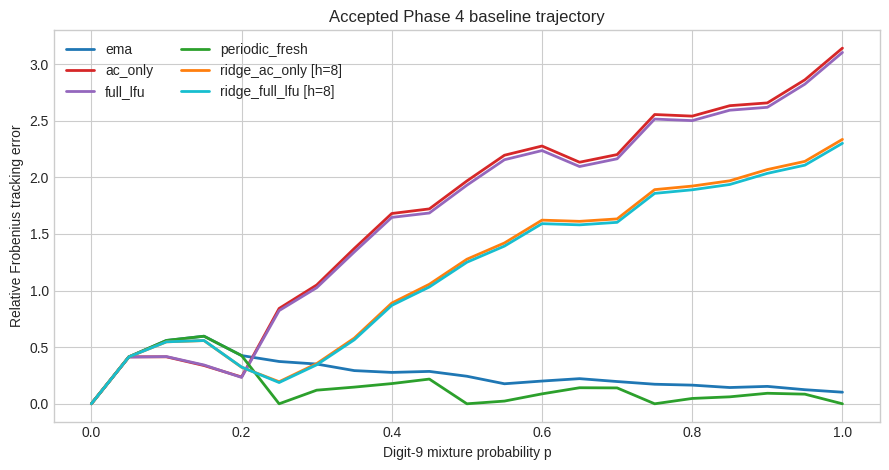

In [10]:
baseline_rows = pd.DataFrame(normalized_phase4_condition_rows([baseline]))
fig, ax = plt.subplots(figsize=(9, 4.8))
for label, group in baseline_rows.groupby("condition_label", sort=False):
    method = group["method"].iloc[0]
    ax.plot(group["p"], group["relative_frobenius_error"], label=label, color=COLORS[method], linewidth=2)
ax.set_xlabel("Digit-9 mixture probability p")
ax.set_ylabel("Relative Frobenius tracking error")
ax.set_title("Accepted Phase 4 baseline trajectory")
ax.legend(ncol=2)
fig.tight_layout()

In [11]:
summary_columns = [
    "replica_id", "num_p_steps", "samples_per_step", "online_observation_budget",
    "ema_gain", "condition_label", "interior_step_count",
    "mean_relative_frobenius_error", "maximum_relative_frobenius_error",
    "mean_applied_correction_fro", "maximum_relative_projection_distance",
]
print(replica_summaries[summary_columns].to_string(index=False, float_format=lambda value: f"{value:.5g}"))

  replica_id  num_p_steps  samples_per_step  online_observation_budget  ema_gain       condition_label  interior_step_count  mean_relative_frobenius_error  maximum_relative_frobenius_error  mean_applied_correction_fro  maximum_relative_projection_distance
replica-0000            9                64                        576      0.25               ac_only                    7                        0.80779                            1.7249                       545.06                            4.4274e-15
replica-0000            9                64                        576      0.25                   ema                    7                        0.52841                           0.73173                            0                            5.3727e-15
replica-0000            9                64                        576      0.25              full_lfu                    7                        0.79319                            1.6899                       536.83               

In [12]:
group_columns = ["num_p_steps", "samples_per_step", "ema_gain", "condition_label"]
aggregate = replica_summaries.groupby(group_columns, dropna=False).agg(
    mean_error=("mean_relative_frobenius_error", "mean"),
    standard_deviation=("mean_relative_frobenius_error", "std"),
    replica_count=("replica_id", "nunique"),
).reset_index()
aggregate["standard_error"] = aggregate["standard_deviation"] / aggregate["replica_count"].pow(0.5)
aggregate["critical_value"] = aggregate["replica_count"].map(
    lambda count: stats.t.ppf(0.975, count - 1) if count >= 2 else math.nan
)
aggregate["ci95_lower"] = aggregate["mean_error"] - aggregate["critical_value"] * aggregate["standard_error"]
aggregate["ci95_upper"] = aggregate["mean_error"] + aggregate["critical_value"] * aggregate["standard_error"]
aggregate["interval_available"] = aggregate["replica_count"] >= 2
print(aggregate.to_string(index=False, float_format=lambda value: f"{value:.5g}"))
if not aggregate["interval_available"].any():
    print("\nNo inferential intervals: every current factor cell has one replica.")

 num_p_steps  samples_per_step  ema_gain       condition_label  mean_error  standard_deviation  replica_count  standard_error  critical_value  ci95_lower  ci95_upper  interval_available
           9                64      0.25               ac_only     0.80779                 NaN              1             NaN             NaN         NaN         NaN               False
           9                64      0.25                   ema     0.52841                 NaN              1             NaN             NaN         NaN         NaN               False
           9                64      0.25              full_lfu     0.79319                 NaN              1             NaN             NaN         NaN         NaN               False
           9                64      0.25        periodic_fresh     0.18333                 NaN              1             NaN             NaN         NaN         NaN               False
           9                64      0.25   ridge_ac_only [h=8]     0.4

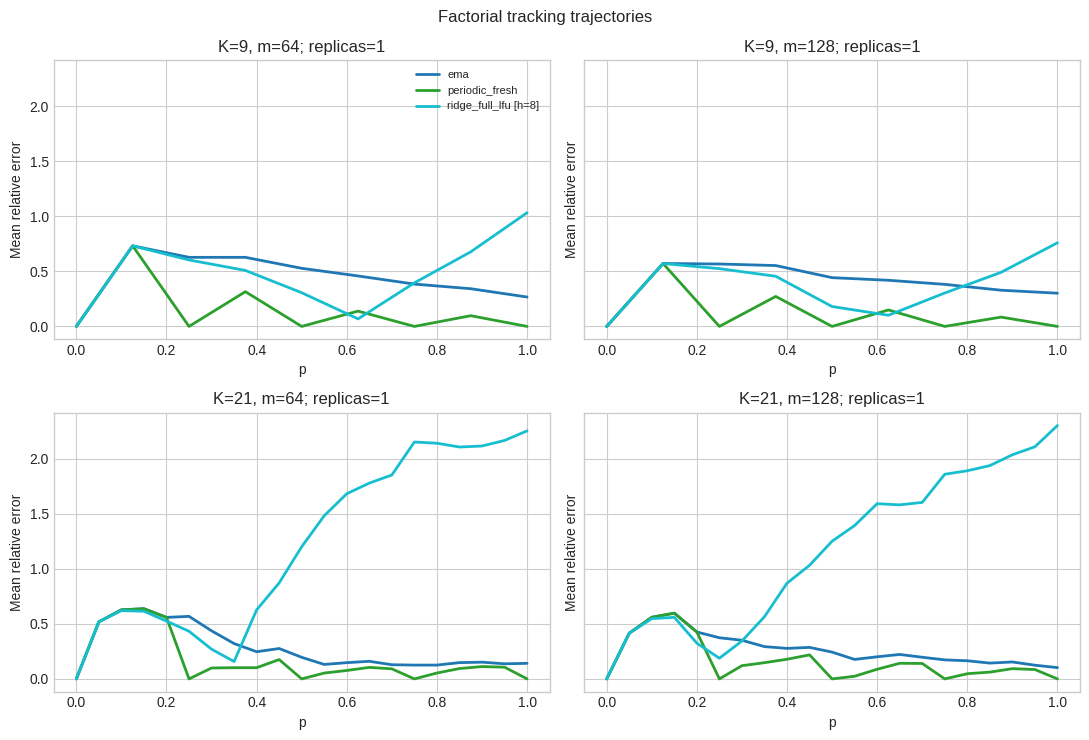

In [13]:
factor_conditions = ["ema", "periodic_fresh", "ridge_full_lfu [h=8]"]
factor_rows = tracking[
    (tracking["ema_gain"] == 0.25)
    & tracking["condition_label"].isin(factor_conditions)
]
trajectory_means = factor_rows.groupby(
    ["num_p_steps", "samples_per_step", "condition_label", "p"],
    as_index=False,
).agg(
    mean_error=("relative_frobenius_error", "mean"),
    standard_deviation=("relative_frobenius_error", "std"),
    replica_count=("replica_id", "nunique"),
)
fig, axes = plt.subplots(2, 2, figsize=(11, 7.5), sharex=False, sharey=True)
for axis, ((steps, samples), cell) in zip(
    axes.flat,
    trajectory_means.groupby(["num_p_steps", "samples_per_step"]),
):
    replica_count = int(cell["replica_count"].max())
    for label, group in cell.groupby("condition_label", sort=False):
        method = "ridge_full_lfu" if label.startswith("ridge_") else label
        axis.plot(group["p"], group["mean_error"], label=label, color=COLORS[method], linewidth=2)
        if replica_count >= 2:
            sem = group["standard_deviation"] / replica_count**0.5
            critical = stats.t.ppf(0.975, replica_count - 1)
            axis.fill_between(group["p"], group["mean_error"] - critical * sem, group["mean_error"] + critical * sem, color=COLORS[method], alpha=0.15)
    axis.set_title(f"K={steps}, m={samples}; replicas={replica_count}")
    axis.set_xlabel("p")
    axis.set_ylabel("Mean relative error")
axes[0, 0].legend(fontsize=8)
fig.suptitle("Factorial tracking trajectories")
fig.tight_layout()

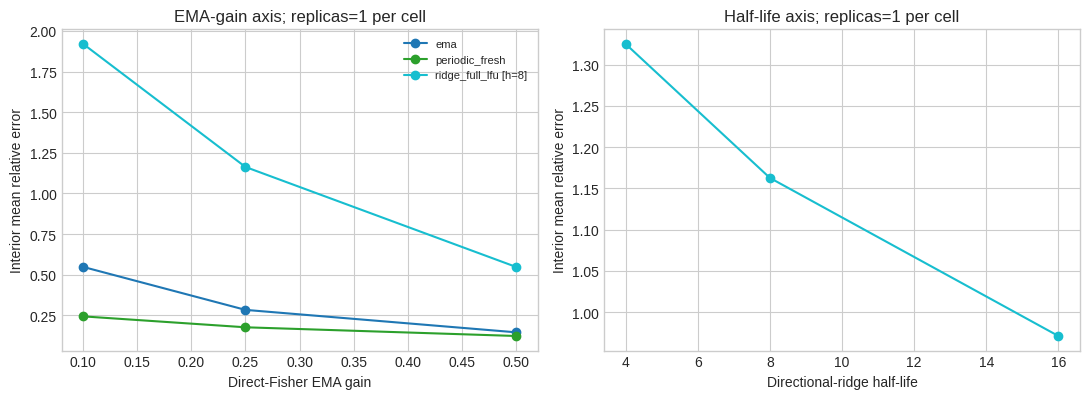

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.1))
ema_axis = replica_summaries[
    (replica_summaries["num_p_steps"] == 21)
    & (replica_summaries["samples_per_step"] == 128)
    & replica_summaries["condition_label"].isin(["ema", "periodic_fresh", "ridge_full_lfu [h=8]"])
]
for label, group in ema_axis.groupby("condition_label", sort=False):
    method = "ridge_full_lfu" if label.startswith("ridge_") else label
    axes[0].plot(group["ema_gain"], group["mean_relative_frobenius_error"], marker="o", label=label, color=COLORS[method])
axes[0].set_xlabel("Direct-Fisher EMA gain")
axes[0].set_ylabel("Interior mean relative error")
axes[0].set_title("EMA-gain axis; replicas=1 per cell")
axes[0].legend(fontsize=8)

half_axis = replica_summaries[
    (replica_summaries["num_p_steps"] == 21)
    & (replica_summaries["samples_per_step"] == 128)
    & (replica_summaries["ema_gain"] == 0.25)
    & (replica_summaries["method"] == "ridge_full_lfu")
].sort_values("ridge_half_life_steps")
axes[1].plot(half_axis["ridge_half_life_steps"], half_axis["mean_relative_frobenius_error"], marker="o", color=COLORS["ridge_full_lfu"])
axes[1].set_xlabel("Directional-ridge half-life")
axes[1].set_ylabel("Interior mean relative error")
axes[1].set_title("Half-life axis; replicas=1 per cell")
fig.tight_layout()

In [15]:
pair_keys = ["replica_id", "trajectory_hash", "design_hash"]
controls = replica_summaries[replica_summaries["method"] == "ema"][pair_keys + ["mean_relative_frobenius_error"]].rename(
    columns={"mean_relative_frobenius_error": "ema_mean_error"}
)
paired = replica_summaries.merge(controls, on=pair_keys, how="left", validate="many_to_one")
paired["paired_error_difference_vs_ema"] = paired["mean_relative_frobenius_error"] - paired["ema_mean_error"]
print(paired[[
    "replica_id", "num_p_steps", "samples_per_step", "ema_gain",
    "condition_label", "paired_error_difference_vs_ema",
]].to_string(index=False, float_format=lambda value: f"{value:.5g}"))

  replica_id  num_p_steps  samples_per_step  ema_gain       condition_label  paired_error_difference_vs_ema
replica-0000            9                64      0.25               ac_only                         0.27938
replica-0000            9                64      0.25                   ema                               0
replica-0000            9                64      0.25              full_lfu                         0.26478
replica-0000            9                64      0.25        periodic_fresh                        -0.34508
replica-0000            9                64      0.25   ridge_ac_only [h=8]                       -0.053763
replica-0000            9                64      0.25  ridge_full_lfu [h=8]                       -0.058317
replica-0000            9               128      0.25               ac_only                         0.45115
replica-0000            9               128      0.25                   ema                               0
replica-0000            9   

## Compute and storage

These are observed costs per immutable run. Content-addressed reference caches may make later runs faster, but each completed run retains its own declared artifacts.

In [16]:
cost_display = costs.copy()
cost_display["peak_cuda_memory_mib"] = cost_display["peak_cuda_memory_bytes"] / 2**20
cost_display["peak_process_rss_mib"] = cost_display["peak_process_rss_bytes"] / 2**20
cost_display["artifact_mib"] = cost_display["artifact_payload_bytes"] / 2**20
print(cost_display[[
    "run_id", "num_p_steps", "samples_per_step", "ema_gain",
    "ridge_half_life_steps", "trajectory_elapsed_seconds",
    "replay_elapsed_seconds", "peak_cuda_memory_mib",
    "peak_process_rss_mib", "artifact_mib",
]].to_string(index=False, float_format=lambda value: f"{value:.5g}"))

                                                      run_id  num_p_steps  samples_per_step  ema_gain  ridge_half_life_steps  trajectory_elapsed_seconds  replay_elapsed_seconds  peak_cuda_memory_mib  peak_process_rss_mib  artifact_mib
mnist_lfu_phase4_ridge_pilot__replica-0000__8294cf954c52cb00           21               128      0.25                      8                      2.6229                  6.3374                446.69                3670.5        269.43
   mnist_lfu_phase5_alpha010__replica-0000__9135e509cabb6c2a           21               128       0.1                      8                      2.3827                  6.4898                446.69                3667.5        269.43
   mnist_lfu_phase5_alpha050__replica-0000__e24f45e4726afd21           21               128       0.5                      8                      2.3724                  6.5233                446.69                  3667        269.43
    mnist_lfu_phase5_k21_m64__replica-0000__15143966ddd1b113

## Reading the pilot

The factor pilot is intended to identify distinguishable tracking regimes and affordable next configurations, not to establish a population result. A later compute contribution adds complete replica trajectories; it does not treat additional points on an existing trajectory as added statistical power.